# YieldSAT Corn/Wheat Yield AOI Baseline

This notebook builds a research-only yield regression baseline from the ready YieldSAT modeling tables, narrows training to `corn` and `wheat`, restricts features to an AOI-compatible imagery-first contract, compares `CatBoost`, `XGBoost`, and `LightGBM`, and then predicts yield for the last known Corn season in `data/aoi_demo_01/`.


## Dependencies

This notebook needs `catboost`, `lightgbm`, and `zarr` in addition to the usual scientific Python stack. The next cell installs only the missing packages so the notebook can run in either the shared project environment or a clean local notebook session.

In [19]:
import importlib.util
import subprocess

required_packages = ["catboost", "lightgbm", "zarr"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call(["uv", "pip", "install", *missing_packages])
else:
    print("All notebook-specific packages are already installed.")

All notebook-specific packages are already installed.


## Imports And Configuration

This section imports the libraries used for grouped regression, feature auditing, AOI season reconstruction, and plotting. It also defines the current transfer-oriented baseline boundary: full-season YieldSAT training, `corn`/`wheat` rows only, the last Corn AOI season (`C3`) as the inference target, and a no-weather default because raw climate signals are likely to transfer poorly from YieldSAT training geographies to the Egypt AOI. Absolute calendar-sensitive features remain removed, and this pass also removes raw Sentinel-2 band summary features so the model relies on vegetation-index shape plus non-calendar observation-quality signals.


In [20]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 42
TARGET_COLUMN = "target_yield_t_ha"
GROUP_COLUMN = "country_year"
TRAIN_CROPS = ["corn", "wheat"]
ACTIVE_TABLE_NAME = "full_season"
INCLUDE_CROP_FEATURE = True
AOI_ID = "aoi_demo_01"
BASELINE_POLICY = "indices_quality_only_no_weather_timing_robust"


def detect_repo_root(max_depth: int = 6) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *list(cwd.parents)[:max_depth]]
    for candidate in candidates:
        if (candidate / "farmtrust_core" / "io" / "paths.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FarmTrust repo root from the current notebook working directory")


REPO_ROOT = detect_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from farmtrust_core.io.paths import aoi_dir



def resolve_existing_dir(base_dir: Path, *relative_candidates: str) -> Path:
    for relative in relative_candidates:
        candidate = (base_dir / relative).resolve()
        if candidate.exists():
            return candidate
    return (base_dir / relative_candidates[0]).resolve()


TABLE_DIR = resolve_existing_dir(
    REPO_ROOT,
    "notebooks/data/yieldsat_final_3_model_tables",
    "data/yieldsat_final_3_model_tables",
)
TABLE_PATHS = {
    "mid_season": TABLE_DIR / "model_mid_season.parquet",
    "near_harvest": TABLE_DIR / "model_near_harvest.parquet",
    "full_season": TABLE_DIR / "model_full_season.parquet",
}

AOI_DIR = aoi_dir(AOI_ID, root=REPO_ROOT / "data")
AOI_CUBE_DIR = AOI_DIR / "cube.zarr"
AOI_INDICES_PATH = AOI_DIR / "indices_timeseries.csv"

AOI_SEASONS = {
    "C1": {"crop": "corn", "start": "2024-05-18", "end": "2024-08-30"},
    "C3": {"crop": "corn", "start": "2025-06-15", "end": "2025-09-11"},
    "C4": {"crop": "alfalfa", "start": "2025-10-05", "end": "2026-05-31"},
}
AOI_TARGET_SEASON_ID = "C3"

AOI_AVAILABLE_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11"]
AOI_AVAILABLE_INDICES = ["NDVI", "EVI", "GNDVI", "NDRE", "NDWI", "SAVI", "MSI"]
AOI_QUALITY_FEATURES = [
    "s2_observation_count",
    "s2_total_images_available",
    "s2_valid_observation_count",
    "s2_valid_pixel_fraction_mean",
    "s2_valid_pixel_fraction_min",
    "s2_max_gap_days",
    "s2_mean_gap_days",
    "s2_first_valid_doy",
    "s2_last_valid_doy",
    "s2_days_since_last_valid",
]
TIMING_SENSITIVE_FEATURES = {
    "season_length_days",
    "s2_first_valid_doy",
    "s2_last_valid_doy",
    "s2_days_since_last_valid",
}
TIMING_SENSITIVE_INDEX_SUFFIXES = ("_peak_doy",)
SUPPORT_ONLY_QUALITY_FEATURES = {
    "s2_valid_pixel_fraction_mean",
    "s2_valid_pixel_fraction_min",
}

print("Notebook cwd:", Path.cwd().resolve())
print("Repo root:", REPO_ROOT)
print("Resolved table directory:", TABLE_DIR)
print("Resolved AOI directory:", AOI_DIR)
print("Active training table:", ACTIVE_TABLE_NAME, TABLE_PATHS[ACTIVE_TABLE_NAME])
print("Train crops:", TRAIN_CROPS)
print("Baseline policy:", BASELINE_POLICY)
print("AOI target season:", AOI_TARGET_SEASON_ID, AOI_SEASONS[AOI_TARGET_SEASON_ID])


Notebook cwd: C:\Users\abdulhamed\Desktop\work\FarmTrust\notebooks
Repo root: C:\Users\abdulhamed\Desktop\work\FarmTrust
Resolved table directory: C:\Users\abdulhamed\Desktop\work\FarmTrust\notebooks\data\yieldsat_final_3_model_tables
Resolved AOI directory: C:\Users\abdulhamed\Desktop\work\FarmTrust\data\aoi_demo_01
Active training table: full_season C:\Users\abdulhamed\Desktop\work\FarmTrust\notebooks\data\yieldsat_final_3_model_tables\model_full_season.parquet
Train crops: ['corn', 'wheat']
Baseline policy: indices_quality_only_no_weather_timing_robust
AOI target season: C3 {'crop': 'corn', 'start': '2025-06-15', 'end': '2025-09-11'}


## Load The Yield Tables And Narrow The Training Set

This section loads the three ready YieldSAT regression tables, confirms their schema boundary, and then narrows the active training frame to `corn` and `wheat` from the full-season table. The grouped validation key is `country_year` so the same country-year slice cannot leak into both train and validation folds.

In [21]:
for table_name, table_path in TABLE_PATHS.items():
    if not table_path.exists():
        raise FileNotFoundError(f"Missing table for {table_name}: {table_path}")

for required_path in [AOI_CUBE_DIR, AOI_INDICES_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(f"Missing AOI input: {required_path}")

tables = {name: pd.read_parquet(path) for name, path in TABLE_PATHS.items()}
shape_summary = pd.DataFrame(
    [{"table": name, "rows": df.shape[0], "columns": df.shape[1]} for name, df in tables.items()]
).sort_values("table").reset_index(drop=True)
display(shape_summary)

active_df = tables[ACTIVE_TABLE_NAME].copy()
active_df["crop"] = active_df["crop"].astype(str).str.lower()
active_df["country"] = active_df["country"].astype(str)
active_df["year"] = active_df["year"].astype(int)
active_df[GROUP_COLUMN] = active_df["country"] + "_" + active_df["year"].astype(str)

train_df = active_df.loc[active_df["crop"].isin(TRAIN_CROPS)].copy().reset_index(drop=True)

print("Active table shape:", active_df.shape)
print("Training subset shape:", train_df.shape)
print("Crop counts:")
display(train_df["crop"].value_counts().rename("rows").to_frame())
print("Country-year group count:", train_df[GROUP_COLUMN].nunique())
print("Target summary by crop:")
display(train_df.groupby("crop")[TARGET_COLUMN].describe().round(3))
print("Rows by country and crop:")
display(pd.crosstab(train_df["country"], train_df["crop"]))


,table,rows,columns
0,full_season,1583,1188
1,mid_season,1583,1204
2,near_harvest,1583,1204


Active table shape: (1583, 1189)
Training subset shape: (757, 1189)
Crop counts:


,rows
crop,
wheat,454
corn,303


Country-year group count: 23
Target summary by crop:


,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
corn,303.0,9.003,2.723,1.856,6.941,8.828,11.271,15.80
wheat,454.0,5.956,2.551,0.651,3.959,5.838,8.210,11.52


Rows by country and crop:


crop,corn,wheat
country,,
Argentina,185,126
Brazil,118,140
Germany,0,188


## Define The AOI-Compatible Feature Contract

The ready YieldSAT tables contain many fields that the AOI cannot reproduce directly, especially SoilGrids, DEM summaries, and some Sentinel-2 bands that are absent from `data/aoi_demo_01/`. This section builds the first inference-safe contract from the overlap we can actually reconstruct: known crop label, season length, AOI-available Sentinel-2 features, and observation-quality metrics. Raw weather is excluded from the default baseline because it is too likely to act as a geography shortcut when training countries differ sharply from the Egypt AOI.


In [22]:
EXCLUDED_METADATA_FEATURES = {
    TARGET_COLUMN,
    "field_id",
    "field_shared_name",
    "country",
    "provider",
    "farm",
    "field_num",
    "year",
    GROUP_COLUMN,
    "adm_country",
    "adm_1",
    "adm_2",
    "adm_3",
    "adm_4",
    "seeding_date",
    "harvesting_date",
    "yieldmap_quality",
    "area_ground_truth_ha",
    "area_calculated_ha",
    "centroid_lat",
    "centroid_lon",
    "crs_epsg",
    "moisture_pct",
}

STATIC_NUMERIC_FEATURES = [
    col for col in ["season_length_days"]
    if col not in TIMING_SENSITIVE_FEATURES
]


def matches_any_prefix(column: str, prefixes: list[str]) -> bool:
    return any(column.startswith(prefix) for prefix in prefixes)


band_prefixes = [f"s2_{band}_" for band in AOI_AVAILABLE_BANDS]
index_prefixes = [f"s2_{index}_" for index in AOI_AVAILABLE_INDICES]

all_band_feature_cols = sorted(
    col for col in train_df.columns
    if col not in EXCLUDED_METADATA_FEATURES and matches_any_prefix(col, band_prefixes)
)
band_feature_cols: list[str] = []
removed_band_feature_cols = all_band_feature_cols.copy()
index_feature_cols = sorted(
    col for col in train_df.columns
    if col not in EXCLUDED_METADATA_FEATURES
    and matches_any_prefix(col, index_prefixes)
    and not col.endswith(TIMING_SENSITIVE_INDEX_SUFFIXES)
)
quality_feature_cols = [
    col for col in AOI_QUALITY_FEATURES
    if col in train_df.columns
    and col not in TIMING_SENSITIVE_FEATURES
    and col not in SUPPORT_ONLY_QUALITY_FEATURES
]
static_numeric_feature_cols = [col for col in STATIC_NUMERIC_FEATURES if col in train_df.columns]
categorical_feature_cols = ["crop"] if INCLUDE_CROP_FEATURE and "crop" in train_df.columns else []
removed_timing_feature_cols = sorted(
    [col for col in train_df.columns if col in TIMING_SENSITIVE_FEATURES]
    + [col for col in train_df.columns if matches_any_prefix(col, index_prefixes) and col.endswith(TIMING_SENSITIVE_INDEX_SUFFIXES)]
)
removed_support_quality_feature_cols = sorted(
    [col for col in AOI_QUALITY_FEATURES if col in train_df.columns and col in SUPPORT_ONLY_QUALITY_FEATURES]
)

numeric_feature_cols = (
    static_numeric_feature_cols
    + band_feature_cols
    + index_feature_cols
    + quality_feature_cols
)

feature_contract_summary = pd.DataFrame(
    [
        {"group": "categorical", "count": len(categorical_feature_cols)},
        {"group": "static_numeric", "count": len(static_numeric_feature_cols)},
        {"group": "s2_band", "count": len(band_feature_cols)},
        {"group": "excluded_s2_band", "count": len(removed_band_feature_cols)},
        {"group": "s2_index", "count": len(index_feature_cols)},
        {"group": "s2_quality", "count": len(quality_feature_cols)},
        {"group": "excluded_support_quality", "count": len(removed_support_quality_feature_cols)},
        {"group": "excluded_timing", "count": len(removed_timing_feature_cols)},
        {"group": "total_numeric", "count": len(numeric_feature_cols)},
    ]
)
display(feature_contract_summary)

print("Excluded raw Sentinel-2 band summary features:", len(removed_band_feature_cols))
print(removed_band_feature_cols[:12])
print("Excluded valid-pixel support features:")
print(removed_support_quality_feature_cols)
print("Excluded timing-sensitive features:")
print(removed_timing_feature_cols)
print("First 20 numeric features:")
print(numeric_feature_cols[:20])
print("Categorical features:", categorical_feature_cols)

X = train_df[numeric_feature_cols + categorical_feature_cols].copy()
y = train_df[TARGET_COLUMN].astype(float).to_numpy()
groups = train_df[GROUP_COLUMN].astype(str).to_numpy()


def make_preprocessor() -> ColumnTransformer:
    transformers = [
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_feature_cols,
        )
    ]
    if categorical_feature_cols:
        transformers.append(
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical_feature_cols,
            )
        )
    return ColumnTransformer(
        transformers=transformers,
        sparse_threshold=0.0,
    ).set_output(transform="pandas")


MODEL_FACTORIES = {
    "catboost": lambda: CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=RANDOM_SEED,
        verbose=False,
        allow_writing_files=False,
    ),
    "xgboost": lambda: XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "lightgbm": lambda: LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        verbose=-1,
    ),
}


def make_pipeline(model_name: str) -> Pipeline:
    return Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", MODEL_FACTORIES[model_name]()),
    ])


,group,count
0,categorical,1
1,static_numeric,0
2,s2_band,0
3,excluded_s2_band,72
4,s2_index,91
5,s2_quality,5
6,excluded_support_quality,2
7,excluded_timing,11
8,total_numeric,96


Excluded raw Sentinel-2 band summary features: 72
['s2_B11_max_mean_of_dates', 's2_B11_mean_mean_of_dates', 's2_B11_min_mean_of_dates', 's2_B11_p10_mean_of_dates', 's2_B11_p25_mean_of_dates', 's2_B11_p75_mean_of_dates', 's2_B11_p90_mean_of_dates', 's2_B11_std_mean_of_dates', 's2_B2_max_mean_of_dates', 's2_B2_mean_mean_of_dates', 's2_B2_min_mean_of_dates', 's2_B2_p10_mean_of_dates']
Excluded valid-pixel support features:
['s2_valid_pixel_fraction_mean', 's2_valid_pixel_fraction_min']
Excluded timing-sensitive features:
['s2_EVI_peak_doy', 's2_GNDVI_peak_doy', 's2_MSI_peak_doy', 's2_NDRE_peak_doy', 's2_NDVI_peak_doy', 's2_NDWI_peak_doy', 's2_SAVI_peak_doy', 's2_days_since_last_valid', 's2_first_valid_doy', 's2_last_valid_doy', 'season_length_days']
First 20 numeric features:
['s2_EVI_auc', 's2_EVI_max', 's2_EVI_mean', 's2_EVI_min', 's2_EVI_p10', 's2_EVI_p25', 's2_EVI_p75', 's2_EVI_p90', 's2_EVI_peak_value', 's2_EVI_range', 's2_EVI_slope_linear', 's2_EVI_slope_start_to_end', 's2_EVI_std',

## Grouped Model Comparison

This section compares `CatBoost`, `XGBoost`, and `LightGBM` under `GroupKFold` validation with `country_year` groups. The goal is not to chase the highest random split score, but to compare model families while preventing the same country-year slice from appearing in both train and validation folds.

In [23]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return {"rmse": rmse, "mae": mae, "r2": r2}


splitter = GroupKFold(n_splits=min(5, len(np.unique(groups))))

cv_rows: list[dict[str, float | int | str]] = []
oof_predictions: dict[str, np.ndarray] = {}
fold_assignments = np.full(len(train_df), -1, dtype=int)

for model_name in MODEL_FACTORIES:
    fold_predictions = np.full(len(train_df), np.nan, dtype=float)

    for fold_index, (train_idx, valid_idx) in enumerate(splitter.split(X, y, groups=groups), start=1):
        if model_name == next(iter(MODEL_FACTORIES)):
            fold_assignments[valid_idx] = fold_index

        pipeline = make_pipeline(model_name)
        pipeline.fit(X.iloc[train_idx], y[train_idx])
        pred = pipeline.predict(X.iloc[valid_idx])
        fold_predictions[valid_idx] = pred

        fold_metrics = regression_metrics(y[valid_idx], pred)
        cv_rows.append(
            {
                "model": model_name,
                "fold": fold_index,
                "rmse": fold_metrics["rmse"],
                "mae": fold_metrics["mae"],
                "r2": fold_metrics["r2"],
                "train_rows": len(train_idx),
                "valid_rows": len(valid_idx),
            }
        )

    oof_predictions[model_name] = fold_predictions

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results.groupby("model", as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
    )
    .sort_values("rmse_mean", ascending=True)
    .reset_index(drop=True)
)

display(cv_summary)
print("Fold-level metrics:")
display(cv_results)

best_model_name = cv_summary.iloc[0]["model"]
print("Best grouped-CV model by RMSE:", best_model_name)

,model,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,catboost,1.856845,0.201038,1.451134,0.181260,0.599598,0.044858
1,lightgbm,1.888841,0.196157,1.449271,0.146950,0.583539,0.062961
2,xgboost,1.908111,0.273158,1.477109,0.198182,0.578923,0.060212


Fold-level metrics:


,model,fold,rmse,mae,r2,train_rows,valid_rows
0,catboost,1,1.713279,1.322816,0.600093,608,149
1,catboost,2,1.593846,1.233686,0.621081,601,156
2,catboost,3,1.951249,1.603367,0.615580,613,144
3,catboost,4,2.097342,1.661411,0.523124,603,154
4,catboost,5,1.928508,1.434392,0.638114,603,154
5,xgboost,1,1.773534,1.357867,0.571470,608,149
6,xgboost,2,1.495668,1.203068,0.666325,601,156
7,xgboost,3,2.148751,1.682153,0.533821,613,144
8,xgboost,4,2.113253,1.634583,0.515861,603,154
9,xgboost,5,2.009347,1.507873,0.607138,603,154


Best grouped-CV model by RMSE: catboost


## Out-Of-Fold Error Review

The grouped CV mean is useful, but it hides where the model misses badly. This section inspects out-of-fold residuals for the best model, checks whether errors differ by crop, and makes the likely domain-shift risks visible before any AOI prediction is trusted.

target_yield_t_ha               predicted_yield_t_ha                \
                   mean median    std                 mean median    std   
crop                                                                       
corn              9.003  8.828  2.723                8.732  8.848  1.468   
wheat             5.956  5.838  2.551                6.289  6.211  2.125   

      abs_error_t_ha                
                mean median    std  
crop                                
corn           1.982  1.734  1.379  
wheat          1.094  0.868  0.847

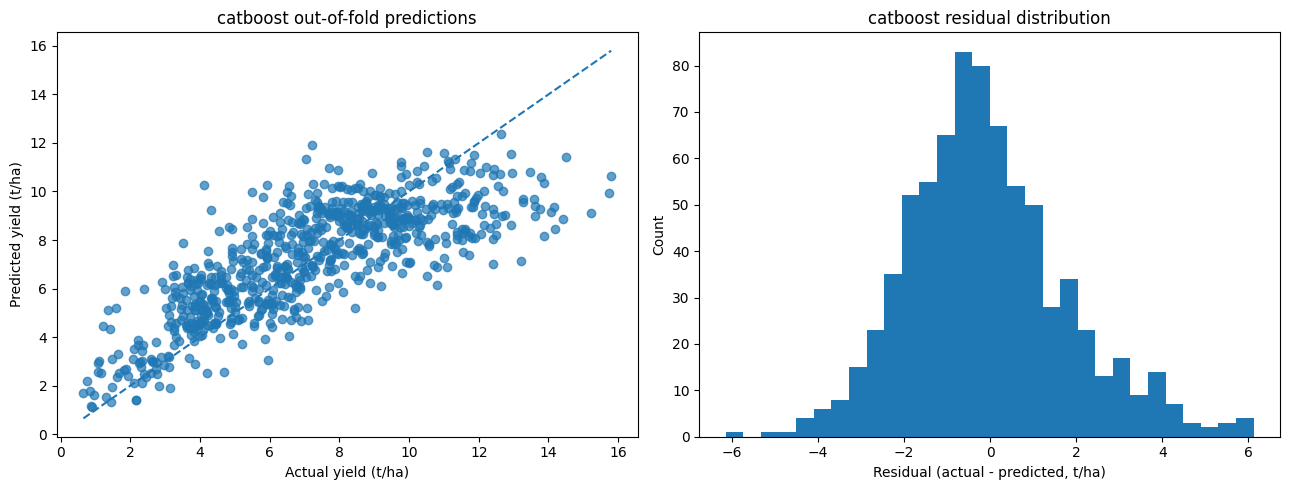

Largest out-of-fold absolute errors:


,crop,country,year,country_year,target_yield_t_ha,fold,predicted_yield_t_ha,residual_t_ha,abs_error_t_ha
226,corn,Argentina,2022,Argentina_2022,4.124000,1,10.268657,-6.144657,6.144657
437,corn,Brazil,2020,Brazil_2020,15.231668,4,9.111094,6.120574,6.120574
263,corn,Argentina,2018,Argentina_2018,13.201000,5,7.133741,6.067259,6.067259
423,corn,Brazil,2020,Brazil_2020,15.740953,4,9.938099,5.802854,5.802854
130,corn,Argentina,2019,Argentina_2019,14.200000,5,8.434469,5.765531,5.765531
434,corn,Brazil,2020,Brazil_2020,13.874882,4,8.173800,5.701082,5.701082
429,corn,Brazil,2023,Brazil_2023,14.414797,3,8.884364,5.530432,5.530432
238,corn,Argentina,2017,Argentina_2017,12.413000,2,7.016858,5.396142,5.396142
301,corn,Argentina,2024,Argentina_2024,15.800000,4,10.634334,5.165666,5.165666
78,corn,Argentina,2023,Argentina_2023,4.300000,4,9.220585,-4.920585,4.920585


In [24]:
best_oof_pred = oof_predictions[best_model_name]
error_review = train_df[["crop", "country", "year", GROUP_COLUMN, TARGET_COLUMN]].copy()
error_review["fold"] = fold_assignments
error_review["predicted_yield_t_ha"] = best_oof_pred
error_review["residual_t_ha"] = error_review[TARGET_COLUMN] - error_review["predicted_yield_t_ha"]
error_review["abs_error_t_ha"] = error_review["residual_t_ha"].abs()

display(
    error_review.groupby("crop")[[TARGET_COLUMN, "predicted_yield_t_ha", "abs_error_t_ha"]]
    .agg(["mean", "median", "std"])
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(error_review[TARGET_COLUMN], error_review["predicted_yield_t_ha"], alpha=0.7)
min_yield = float(error_review[[TARGET_COLUMN, "predicted_yield_t_ha"]].min().min())
max_yield = float(error_review[[TARGET_COLUMN, "predicted_yield_t_ha"]].max().max())
axes[0].plot([min_yield, max_yield], [min_yield, max_yield], linestyle="--")
axes[0].set_title(f"{best_model_name} out-of-fold predictions")
axes[0].set_xlabel("Actual yield (t/ha)")
axes[0].set_ylabel("Predicted yield (t/ha)")

axes[1].hist(error_review["residual_t_ha"].dropna(), bins=30)
axes[1].set_title(f"{best_model_name} residual distribution")
axes[1].set_xlabel("Residual (actual - predicted, t/ha)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Largest out-of-fold absolute errors:")
display(error_review.sort_values("abs_error_t_ha", ascending=False).head(15))

## Fit The Selected Baseline And Inspect Feature Importance

This section refits the best-performing grouped-CV model on all available `corn`/`wheat` rows so the notebook has one reusable baseline for AOI inference. Native feature importance is then summarized both by individual transformed feature and by broader source group.

In [25]:
best_pipeline = make_pipeline(best_model_name)
best_pipeline.fit(X, y)

transformed_feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()
feature_importance = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "importance": best_pipeline.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False).reset_index(drop=True)


def feature_source(feature_name: str) -> str:
    if feature_name.startswith("cat__crop_"):
        return "crop"
    raw_name = feature_name.split("__", 1)[1] if "__" in feature_name else feature_name
    if raw_name in static_numeric_feature_cols:
        return "season"
    if raw_name in quality_feature_cols:
        return "s2_quality"
    if raw_name in band_feature_cols:
        return "s2_band"
    if raw_name in index_feature_cols:
        return "s2_index"
    return "other"


feature_importance["source"] = feature_importance["feature"].map(feature_source)
importance_by_source = (
    feature_importance.groupby("source", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top transformed features:")
display(feature_importance.head(30))
print("Importance by source:")
display(importance_by_source)


Top transformed features:


,feature,importance,source
0,cat__crop_wheat,18.088695,crop
1,cat__crop_corn,14.458724,crop
2,num__s2_EVI_auc,7.418179,s2_index
3,num__s2_NDRE_auc,2.545776,s2_index
4,num__s2_NDWI_auc,2.493130,s2_index
5,num__s2_GNDVI_auc,2.114919,s2_index
6,num__s2_EVI_std,1.842593,s2_index
7,num__s2_mean_gap_days,1.817179,s2_quality
8,num__s2_GNDVI_slope_linear,1.471726,s2_index
9,num__s2_NDRE_std,1.388051,s2_index


Importance by source:


,source,importance
0,s2_index,63.961668
1,crop,32.547419
2,s2_quality,3.490913


## Rebuild One AOI Season As A Training-Compatible Feature Row

The AOI directory does not come as a ready-made YieldSAT regression table, so this section reconstructs one season row from the actual AOI assets. It still reads the Sentinel-2 cube and computes band summaries because those are needed to derive the AOI-compatible vegetation indices, then derives non-calendar quality features from `indices_timeseries.csv`. `valid_fraction` stays in the reconstruction path as an internal support signal for selecting usable dates, but the model input later keeps only the timing-robust index-plus-quality subset selected above.


In [26]:
TRAIN_BAND_TO_AOI_VAR = {
    "B2": "B02",
    "B3": "B03",
    "B4": "B04",
    "B5": "B05",
    "B6": "B06",
    "B7": "B07",
    "B8": "B08",
    "B8A": "B8A",
    "B11": "B11",
}


def safe_div(numerator, denominator):
    if isinstance(denominator, pd.Series):
        denominator = denominator.replace(0, np.nan)
    elif denominator == 0:
        denominator = np.nan
    return numerator / denominator



def stable_std(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) <= 1:
        return 0.0
    return float(series.std(ddof=0))



def stable_quantile(series: pd.Series, q: float) -> float:
    series = series.dropna()
    if series.empty:
        return np.nan
    return float(series.quantile(q))



def stable_auc(values: np.ndarray, offsets: np.ndarray) -> float:
    if len(values) < 2:
        return 0.0
    return float(np.trapezoid(values, x=offsets))



def summarise_band_series(series: pd.Series, band_name: str) -> dict[str, float]:
    series = series.dropna().sort_index()
    prefix = f"s2_{band_name}"
    if series.empty:
        return {
            f"{prefix}_mean_mean_of_dates": np.nan,
            f"{prefix}_std_mean_of_dates": np.nan,
            f"{prefix}_min_mean_of_dates": np.nan,
            f"{prefix}_max_mean_of_dates": np.nan,
            f"{prefix}_p10_mean_of_dates": np.nan,
            f"{prefix}_p25_mean_of_dates": np.nan,
            f"{prefix}_p75_mean_of_dates": np.nan,
            f"{prefix}_p90_mean_of_dates": np.nan,
        }
    return {
        f"{prefix}_mean_mean_of_dates": float(series.mean()),
        f"{prefix}_std_mean_of_dates": stable_std(series),
        f"{prefix}_min_mean_of_dates": float(series.min()),
        f"{prefix}_max_mean_of_dates": float(series.max()),
        f"{prefix}_p10_mean_of_dates": stable_quantile(series, 0.10),
        f"{prefix}_p25_mean_of_dates": stable_quantile(series, 0.25),
        f"{prefix}_p75_mean_of_dates": stable_quantile(series, 0.75),
        f"{prefix}_p90_mean_of_dates": stable_quantile(series, 0.90),
    }



def summarise_index_series(series: pd.Series, index_name: str) -> dict[str, float]:
    series = series.dropna().sort_index()
    prefix = f"s2_{index_name}"
    if series.empty:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_p10": np.nan,
            f"{prefix}_p25": np.nan,
            f"{prefix}_p75": np.nan,
            f"{prefix}_p90": np.nan,
            f"{prefix}_range": np.nan,
            f"{prefix}_peak_value": np.nan,
            f"{prefix}_peak_doy": np.nan,
            f"{prefix}_auc": np.nan,
            f"{prefix}_slope_linear": np.nan,
            f"{prefix}_slope_start_to_end": np.nan,
        }

    series_values = series.to_numpy(dtype=float)
    day_offsets = (series.index - series.index.min()).days.to_numpy(dtype=float)
    slope_linear = float(np.polyfit(day_offsets, series_values, 1)[0]) if len(series_values) >= 2 else 0.0
    total_day_span = float(day_offsets[-1]) if len(day_offsets) > 0 else 0.0
    slope_start_to_end = float((series_values[-1] - series_values[0]) / total_day_span) if total_day_span > 0 else 0.0
    peak_timestamp = series.idxmax()

    return {
        f"{prefix}_mean": float(series.mean()),
        f"{prefix}_std": stable_std(series),
        f"{prefix}_min": float(series.min()),
        f"{prefix}_max": float(series.max()),
        f"{prefix}_p10": stable_quantile(series, 0.10),
        f"{prefix}_p25": stable_quantile(series, 0.25),
        f"{prefix}_p75": stable_quantile(series, 0.75),
        f"{prefix}_p90": stable_quantile(series, 0.90),
        f"{prefix}_range": float(series.max() - series.min()),
        f"{prefix}_peak_value": float(series.max()),
        f"{prefix}_peak_doy": int(pd.Timestamp(peak_timestamp).dayofyear),
        f"{prefix}_auc": stable_auc(series_values, day_offsets),
        f"{prefix}_slope_linear": slope_linear,
        f"{prefix}_slope_start_to_end": slope_start_to_end,
    }



def load_aoi_band_daily_means(cube_dir: Path) -> pd.DataFrame:
    root_ds = xr.open_zarr(str(cube_dir), consolidated=False)
    ds_20m = xr.open_zarr(str(cube_dir), group="20m", consolidated=False)

    band_series = []
    for train_band, aoi_var_name in TRAIN_BAND_TO_AOI_VAR.items():
        if aoi_var_name in root_ds.data_vars:
            source = root_ds[aoi_var_name]
        elif aoi_var_name in ds_20m.data_vars:
            source = ds_20m[aoi_var_name]
        else:
            raise KeyError(f"AOI cube is missing required band variable: {aoi_var_name}")

        spatial_dims = [dim for dim in source.dims if dim != "time"]
        reflectance = ((source.astype("float32") - 1000.0) / 10000.0).where(source > 0)
        daily_mean = reflectance.mean(dim=spatial_dims, skipna=True).to_series().rename(train_band)
        daily_mean.index = pd.to_datetime(daily_mean.index)
        band_series.append(daily_mean)

    band_df = pd.concat(band_series, axis=1).reset_index()
    first_column_name = band_df.columns[0]
    band_df = band_df.rename(columns={first_column_name: "solar_day"})
    band_df["solar_day"] = pd.to_datetime(band_df["solar_day"])
    return band_df.sort_values("solar_day").reset_index(drop=True)


indices_df = pd.read_csv(AOI_INDICES_PATH)
indices_df["solar_day"] = pd.to_datetime(indices_df["solar_day"])

season_info = AOI_SEASONS[AOI_TARGET_SEASON_ID]
season_start = pd.Timestamp(season_info["start"])
season_end = pd.Timestamp(season_info["end"])
season_crop = str(season_info["crop"]).lower()
season_length_days = int((season_end - season_start).days + 1)

band_daily_means = load_aoi_band_daily_means(AOI_CUBE_DIR)
aoi_band_slice = band_daily_means.loc[
    (band_daily_means["solar_day"] >= season_start) & (band_daily_means["solar_day"] <= season_end)
].copy()

indices_slice = indices_df.loc[
    (indices_df["solar_day"] >= season_start) & (indices_df["solar_day"] <= season_end),
    ["solar_day", "valid_fraction"],
].copy()

aoi_daily = aoi_band_slice.merge(indices_slice, on="solar_day", how="left").sort_values("solar_day").reset_index(drop=True)
aoi_daily["valid_fraction"] = aoi_daily["valid_fraction"].fillna(0.0)
valid_daily = aoi_daily.loc[aoi_daily["valid_fraction"] > 0].copy()

if valid_daily.empty:
    raise ValueError("The target AOI season has no valid Sentinel-2 observations after quality filtering")

valid_daily_indexed = valid_daily.set_index("solar_day")

b2 = valid_daily["B2"].astype(float)
b3 = valid_daily["B3"].astype(float)
b4 = valid_daily["B4"].astype(float)
b5 = valid_daily["B5"].astype(float)
b8 = valid_daily["B8"].astype(float)
b11 = valid_daily["B11"].astype(float)

for index_name, values in {
    "NDVI": safe_div(b8 - b4, b8 + b4),
    "EVI": safe_div(2.5 * (b8 - b4), b8 + (6.0 * b4) - (7.5 * b2) + 1.0),
    "GNDVI": safe_div(b8 - b3, b8 + b3),
    "NDRE": safe_div(b8 - b5, b8 + b5),
    "NDWI": safe_div(b8 - b11, b8 + b11),
    "SAVI": safe_div(1.5 * (b8 - b4), b8 + b4 + 0.5),
    "MSI": safe_div(b11, b8),
}.items():
    valid_daily_indexed[index_name] = values.to_numpy(dtype=float)

valid_dates = valid_daily_indexed.index.to_series().sort_values()
gap_days = valid_dates.diff().dropna().dt.days.astype(int)

quality_summary = {
    "s2_observation_count": int(len(aoi_daily)),
    "s2_total_images_available": int(len(aoi_daily)),
    "s2_valid_observation_count": int(len(valid_daily_indexed)),
    "s2_valid_pixel_fraction_mean": float(valid_daily_indexed["valid_fraction"].mean()),
    "s2_valid_pixel_fraction_min": float(valid_daily_indexed["valid_fraction"].min()),
    "s2_max_gap_days": int(gap_days.max()) if not gap_days.empty else 0,
    "s2_mean_gap_days": float(gap_days.mean()) if not gap_days.empty else 0.0,
    "s2_first_valid_doy": int(valid_dates.iloc[0].dayofyear),
    "s2_last_valid_doy": int(valid_dates.iloc[-1].dayofyear),
    "s2_days_since_last_valid": int((season_end - valid_dates.iloc[-1]).days),
}

feature_row = {
    "crop": season_crop,
    "season_length_days": season_length_days,
}

for band_name in AOI_AVAILABLE_BANDS:
    feature_row.update(summarise_band_series(valid_daily_indexed[band_name], band_name))

for index_name in AOI_AVAILABLE_INDICES:
    feature_row.update(summarise_index_series(valid_daily_indexed[index_name], index_name))

feature_row.update(quality_summary)

aoi_feature_row = pd.DataFrame([feature_row])
required_feature_cols = numeric_feature_cols + categorical_feature_cols
missing_required_features = [feature for feature in required_feature_cols if feature not in aoi_feature_row.columns]
if missing_required_features:
    raise ValueError(f"AOI feature row is missing required training features: {missing_required_features}")

print("AOI target season:", AOI_TARGET_SEASON_ID, season_crop, season_start.date(), season_end.date())
print("AOI season rows:", len(aoi_daily), "valid rows:", len(valid_daily_indexed))
print("AOI feature row columns:", len(aoi_feature_row.columns))
display(aoi_feature_row[required_feature_cols[:20]])


AOI target season: C3 corn 2025-06-15 2025-09-11
AOI season rows: 41 valid rows: 39
AOI feature row columns: 182


,s2_EVI_auc,s2_EVI_max,s2_EVI_mean,s2_EVI_min,s2_EVI_p10,s2_EVI_p25,s2_EVI_p75,s2_EVI_p90,s2_EVI_peak_value,s2_EVI_range,s2_EVI_slope_linear,s2_EVI_slope_start_to_end,s2_EVI_std,s2_GNDVI_auc,s2_GNDVI_max,s2_GNDVI_mean,s2_GNDVI_min,s2_GNDVI_p10,s2_GNDVI_p25,s2_GNDVI_p75
0,37.585862,0.671567,0.434032,0.119947,0.214201,0.290328,0.559271,0.626895,0.671567,0.55162,0.000433,-0.000713,0.156356,51.111129,0.762054,0.586126,0.119692,0.393517,0.478019,0.685131


## Predict Yield For The Last Corn AOI Season

This final section fits all three regressors on the full `corn`/`wheat` training subset, applies the reconstructed AOI season row, and compares the resulting yield estimates. Because the AOI archive does not currently include a linked ground-truth yield value, this is a plausibility-oriented inference check rather than a scored validation result.

In [27]:
import json

KG_PER_TON = 1000.0
FEDDAN_PER_HECTARE = 2.381
SQM_PER_HECTARE = 10000.0
KG_PER_FEDDAN_PER_T_HA = KG_PER_TON / FEDDAN_PER_HECTARE

with (AOI_DIR / "run_metadata.json").open("r", encoding="utf-8") as fh:
    run_metadata = json.load(fh)

plot_coords = run_metadata["geometry"]["coordinates"][0]
plot_area_sqm = 0.0
for idx in range(len(plot_coords) - 1):
    lon1, lat1 = plot_coords[idx]
    lon2, lat2 = plot_coords[idx + 1]
    mean_lat_rad = np.radians((lat1 + lat2) / 2.0)
    x1 = lon1 * 111320.0 * np.cos(mean_lat_rad)
    y1 = lat1 * 111320.0
    x2 = lon2 * 111320.0 * np.cos(mean_lat_rad)
    y2 = lat2 * 111320.0
    plot_area_sqm += (x1 * y2) - (x2 * y1)
plot_area_sqm = abs(plot_area_sqm) / 2.0
plot_area_ha = plot_area_sqm / SQM_PER_HECTARE
plot_area_feddan = plot_area_ha * FEDDAN_PER_HECTARE

aoi_model_input = aoi_feature_row[required_feature_cols].copy()
best_prediction_t_ha = float(best_pipeline.predict(aoi_model_input)[0])
best_prediction_kg_feddan = best_prediction_t_ha * KG_PER_FEDDAN_PER_T_HA
best_prediction_plot_kg = best_prediction_t_ha * KG_PER_TON * plot_area_ha

corn_reference_t_ha = train_df.loc[train_df["crop"] == season_crop, TARGET_COLUMN].astype(float)
corn_reference_kg_feddan = corn_reference_t_ha * KG_PER_FEDDAN_PER_T_HA
best_prediction_percentile = float((corn_reference_t_ha <= best_prediction_t_ha).mean())

aoi_predictions = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "predicted_yield_t_ha": best_prediction_t_ha,
            "predicted_yield_kg_feddan": best_prediction_kg_feddan,
            "predicted_yield_plot_kg": best_prediction_plot_kg,
            "plot_area_feddan": plot_area_feddan,
            "corn_train_percentile": best_prediction_percentile,
        }
    ]
)

display(aoi_predictions.round({
    "predicted_yield_t_ha": 3,
    "predicted_yield_kg_feddan": 1,
    "predicted_yield_plot_kg": 1,
    "plot_area_feddan": 3,
    "corn_train_percentile": 3,
}))
print("Best grouped-CV model:", best_model_name)
print("AOI season:", AOI_TARGET_SEASON_ID, season_crop, season_start.date(), season_end.date())
print("Plot area (m^2):", round(plot_area_sqm, 1))
print("Plot area (ha):", round(plot_area_ha, 4))
print("Plot area (feddan):", round(plot_area_feddan, 3))
print("Predicted yield (t/ha):", round(best_prediction_t_ha, 3))
print("Predicted yield (kg/feddan):", round(best_prediction_kg_feddan, 1))
print("Predicted yield (whole plot kg):", round(best_prediction_plot_kg, 1))
print("Corn training percentile:", round(best_prediction_percentile, 3))
print("Corn training reference in kg/feddan:")
display(corn_reference_kg_feddan.describe().round(1).to_frame("corn_training_yield_kg_feddan"))


,model,predicted_yield_t_ha,predicted_yield_kg_feddan,predicted_yield_plot_kg,plot_area_feddan,corn_train_percentile
0,catboost,8.079,3393.3,1032.3,0.304,0.429


Best grouped-CV model: catboost
AOI season: C3 corn 2025-06-15 2025-09-11
Plot area (m^2): 1277.8
Plot area (ha): 0.1278
Plot area (feddan): 0.304
Predicted yield (t/ha): 8.079
Predicted yield (kg/feddan): 3393.3
Predicted yield (whole plot kg): 1032.3
Corn training percentile: 0.429
Corn training reference in kg/feddan:


,corn_training_yield_kg_feddan
count,303.0
mean,3781.3
std,1143.5
min,779.5
25%,2915.0
50%,3707.7
75%,4733.7
max,6635.9


## Appendix: PLS Regression Check

This appendix tests a latent-factor linear regressor under the same `GroupKFold` setup used above. `PLSRegression` offers a different bias than the tree ensembles and is a useful transfer-oriented check when the input features are numerous and strongly correlated.

In [28]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler


def make_pls_pipeline(n_components: int) -> Pipeline:
    return Pipeline([
        ("preprocessor", make_preprocessor()),
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_components, scale=False)),
    ])


pls_feature_probe = make_preprocessor()
pls_feature_probe.fit(X)
pls_feature_names = pls_feature_probe.get_feature_names_out().tolist()

fold_splits = list(splitter.split(X, y, groups=groups))
min_fold_train_rows = min(len(train_idx) for train_idx, _ in fold_splits)
max_pls_components = min(len(pls_feature_names), max(1, min_fold_train_rows - 1))
candidate_pls_components = [n for n in [2, 4, 8, 12, 16, 24, 32] if n <= max_pls_components]
if not candidate_pls_components:
    candidate_pls_components = [1]

pls_cv_rows: list[dict[str, float | int | str]] = []
pls_oof_predictions: dict[int, np.ndarray] = {}

for n_components in candidate_pls_components:
    fold_predictions = np.full(len(train_df), np.nan, dtype=float)

    for fold_index, (train_idx, valid_idx) in enumerate(fold_splits, start=1):
        pls_pipeline = make_pls_pipeline(n_components)
        pls_pipeline.fit(X.iloc[train_idx], y[train_idx])
        pred = np.asarray(pls_pipeline.predict(X.iloc[valid_idx])).reshape(-1)
        fold_predictions[valid_idx] = pred

        fold_metrics = regression_metrics(y[valid_idx], pred)
        pls_cv_rows.append(
            {
                "model": "pls",
                "n_components": n_components,
                "fold": fold_index,
                "rmse": fold_metrics["rmse"],
                "mae": fold_metrics["mae"],
                "r2": fold_metrics["r2"],
                "train_rows": len(train_idx),
                "valid_rows": len(valid_idx),
            }
        )

    pls_oof_predictions[n_components] = fold_predictions

pls_cv_results = pd.DataFrame(pls_cv_rows)
pls_cv_summary = (
    pls_cv_results.groupby("n_components", as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
    )
    .sort_values("rmse_mean", ascending=True)
    .reset_index(drop=True)
)

best_pls_components = int(pls_cv_summary.iloc[0]["n_components"])
best_pls_pipeline = make_pls_pipeline(best_pls_components)
best_pls_pipeline.fit(X, y)

best_pls_prediction_t_ha = float(np.asarray(best_pls_pipeline.predict(aoi_model_input)).reshape(-1)[0])
best_pls_prediction_kg_feddan = best_pls_prediction_t_ha * KG_PER_FEDDAN_PER_T_HA
best_pls_prediction_plot_kg = best_pls_prediction_t_ha * KG_PER_TON * plot_area_ha
best_pls_prediction_percentile = float((corn_reference_t_ha <= best_pls_prediction_t_ha).mean())

pls_predictions = pd.DataFrame(
    [
        {
            "model": f"pls_{best_pls_components}c",
            "predicted_yield_t_ha": best_pls_prediction_t_ha,
            "predicted_yield_kg_feddan": best_pls_prediction_kg_feddan,
            "predicted_yield_plot_kg": best_pls_prediction_plot_kg,
            "plot_area_feddan": plot_area_feddan,
            "corn_train_percentile": best_pls_prediction_percentile,
        }
    ]
)

pls_coefficients = pd.DataFrame(
    {
        "feature": pls_feature_names,
        "coefficient": np.asarray(best_pls_pipeline.named_steps["model"].coef_).reshape(-1),
    }
)
pls_coefficients["abs_coefficient"] = pls_coefficients["coefficient"].abs()
pls_coefficients["source"] = pls_coefficients["feature"].map(feature_source)
pls_coefficients = pls_coefficients.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
pls_coefficient_by_source = (
    pls_coefficients.groupby("source", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

pls_vs_baseline = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "grouped_cv_rmse": float(cv_summary.loc[cv_summary["model"] == best_model_name, "rmse_mean"].iloc[0]),
            "predicted_yield_t_ha": best_prediction_t_ha,
            "predicted_yield_kg_feddan": best_prediction_kg_feddan,
            "predicted_yield_plot_kg": best_prediction_plot_kg,
            "corn_train_percentile": best_prediction_percentile,
        },
        {
            "model": f"pls_{best_pls_components}c",
            "grouped_cv_rmse": float(pls_cv_summary.iloc[0]["rmse_mean"]),
            "predicted_yield_t_ha": best_pls_prediction_t_ha,
            "predicted_yield_kg_feddan": best_pls_prediction_kg_feddan,
            "predicted_yield_plot_kg": best_pls_prediction_plot_kg,
            "corn_train_percentile": best_pls_prediction_percentile,
        },
    ]
)

print("PLS component sweep:")
display(pls_cv_summary.round(3))
print("Selected PLS components:", best_pls_components)
print("PLS AOI prediction:")
display(pls_predictions.round(
    {
        "predicted_yield_t_ha": 3,
        "predicted_yield_kg_feddan": 1,
        "predicted_yield_plot_kg": 1,
        "plot_area_feddan": 3,
        "corn_train_percentile": 3,
    }
))
print("Baseline vs PLS comparison:")
display(pls_vs_baseline.round(
    {
        "grouped_cv_rmse": 3,
        "predicted_yield_t_ha": 3,
        "predicted_yield_kg_feddan": 1,
        "predicted_yield_plot_kg": 1,
        "corn_train_percentile": 3,
    }
))
print("Top PLS coefficients by magnitude:")
display(pls_coefficients.head(30).round({"coefficient": 4, "abs_coefficient": 4}))
print("PLS coefficient magnitude by source:")
display(pls_coefficient_by_source.round(4))

PLS component sweep:


,n_components,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,8,2.070,0.415,1.545,0.194,0.488,0.199
1,4,2.425,1.016,1.669,0.361,0.234,0.658
2,2,2.842,1.052,2.037,0.333,-0.015,0.757
3,12,2.976,2.333,1.662,0.342,-0.465,2.271
4,16,3.702,3.568,1.828,0.457,-1.628,4.671
5,24,4.153,3.682,1.926,0.504,-2.124,5.074
6,32,4.558,4.086,2.009,0.574,-2.839,6.018


Selected PLS components: 8
PLS AOI prediction:


,model,predicted_yield_t_ha,predicted_yield_kg_feddan,predicted_yield_plot_kg,plot_area_feddan,corn_train_percentile
0,pls_8c,8.34,3502.8,1065.7,0.304,0.446


Baseline vs PLS comparison:


,model,grouped_cv_rmse,predicted_yield_t_ha,predicted_yield_kg_feddan,predicted_yield_plot_kg,corn_train_percentile
0,catboost,1.857,8.079,3393.3,1032.3,0.429
1,pls_8c,2.070,8.340,3502.8,1065.7,0.446


Top PLS coefficients by magnitude:


,feature,coefficient,abs_coefficient,source
0,cat__crop_corn,1.1984,1.1984,crop
1,cat__crop_wheat,-1.1984,1.1984,crop
2,num__s2_NDWI_auc,0.4165,0.4165,s2_index
3,num__s2_NDWI_min,0.4087,0.4087,s2_index
4,num__s2_NDRE_std,0.2758,0.2758,s2_index
5,num__s2_NDRE_auc,0.2601,0.2601,s2_index
6,num__s2_SAVI_auc,0.2452,0.2452,s2_index
7,num__s2_NDWI_range,-0.2292,0.2292,s2_index
8,num__s2_NDWI_p10,0.2094,0.2094,s2_index
9,num__s2_NDVI_peak_value,-0.1888,0.1888,s2_index


PLS coefficient magnitude by source:


,source,abs_coefficient
0,s2_index,8.3808
1,crop,2.3969
2,s2_quality,0.4137
